# LAB12 - Hartëzimi i Fushës Magnetike

## Qëllimi i laboratorit

Qëllimi i këtij laboratori është të studiojmë fushën magnetike duke përdorur matje nga magnetometri i telefonit.

Telefoni mat tre komponentë të fushës magnetike:

- \(B_x\)
- \(B_y\)
- \(B_z\)

Nga këto komponentë llogaritet fusha totale magnetike:

\[
B = \sqrt{B_x^2 + B_y^2 + B_z^2}
\]

Në këtë notebook trajtohen vetëm:

- Eksperimenti A: fusha magnetike e ambientit
- Eksperimenti B: fusha magnetike në një vijë pranë magnetit
- Eksperimenti C: harta 2D e fushës magnetike

## Përgatitja e të dhënave

File-t CSV janë vendosur në folderin `data`.

Struktura e folderit është:

```text
LAB12/
├── data/
│   ├── B_ambienti.csv
│   ├── B_1D.csv
│   └── B_map_2D.csv
├── figs/
└── Raport_LAB12.ipynb
```

Folderi `figs` përdoret për të ruajtur grafikët.

## Importimi i librarive

Këtu importojmë libraritë që na duhen për të lexuar file-t CSV dhe për të bërë grafikët.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

data_folder = "data"
figs_folder = "figs"

os.makedirs(figs_folder, exist_ok=True)

## Kontrolli i të dhënave

Shfaqim disa rreshta të parë për të parë nëse të dhënat janë lexuar saktë.

In [4]:
print("Eksperimenti A - Ambjenti")
display(ambienti.head())

print("Eksperimenti B - Matja 1D")
display(b_1d.head())

print("Eksperimenti C - Harta 2D")
display(b_map.head())

Eksperimenti A - Ambjenti


,time_s,Bx_uT,By_uT,Bz_uT,B_total_uT
0,0,21.96,-5.34,39.27,45.31
1,1,21.50,-5.99,38.80,44.76
2,2,21.68,-5.19,39.30,45.19
3,3,22.14,-5.44,39.26,45.40
4,4,21.50,-5.56,38.46,44.41


Eksperimenti B - Matja 1D


,distance_cm,Bx_uT,By_uT,Bz_uT,B_total_uT
0,2,181.77,-6.46,127.70,222.23
1,4,70.47,-6.28,65.40,96.35
2,6,48.94,-6.98,52.04,71.78
3,8,36.06,-6.40,47.07,59.64
4,10,30.98,-4.24,44.71,54.56


Eksperimenti C - Harta 2D


,x_cm,y_cm,Bx_uT,By_uT,Bz_uT,B_total_uT
0,0,0,13.74,-12.82,46.62,50.27
1,2,0,14.24,-16.15,48.22,52.81
2,4,0,18.25,-20.85,50.17,57.31
3,6,0,21.55,-22.49,49.97,58.88
4,8,0,27.17,-21.43,49.05,60.02


# Eksperimenti A - Fusha Magnetike e Ambientit

Në eksperimentin A matet fusha magnetike e ambientit.

Telefoni mbahet pa lëvizur për disa sekonda dhe regjistrohen vlerat e \(B_x\), \(B_y\), \(B_z\) dhe \(B_{total}\).

Kjo matje përdoret si vlerë bazë për të krahasuar matjet pranë magnetit.

## Përpunimi i të dhënave për Eksperimentin A

Llogarisim:

- vlerën mesatare të fushës magnetike
- vlerën minimale
- vlerën maksimale

In [5]:
B_ambient_mean = ambienti["B_total_uT"].mean()
B_ambient_min = ambienti["B_total_uT"].min()
B_ambient_max = ambienti["B_total_uT"].max()

print("Mesatarja e fushës së ambientit:", round(B_ambient_mean, 2), "uT")
print("Vlera minimale:", round(B_ambient_min, 2), "uT")
print("Vlera maksimale:", round(B_ambient_max, 2), "uT")

Mesatarja e fushës së ambientit: 45.08 uT
Vlera minimale: 44.34 uT
Vlera maksimale: 46.06 uT


## Grafiku i fushës magnetike të ambientit

Ky grafik tregon si ndryshon fusha magnetike e ambientit me kohën.

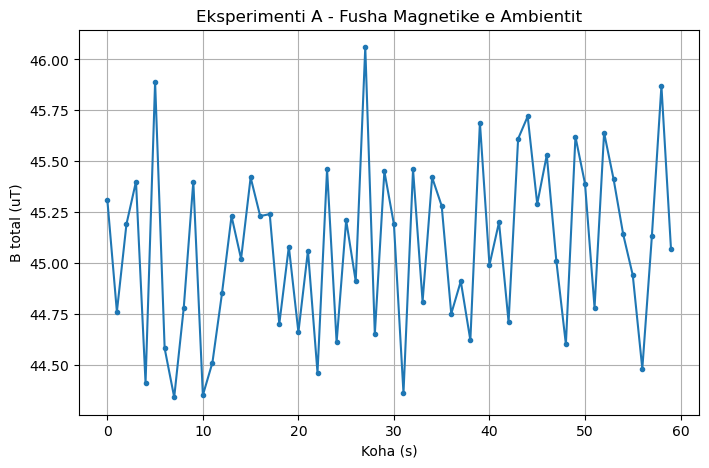

In [6]:
plt.figure(figsize=(8, 5))
plt.plot(ambienti["time_s"], ambienti["B_total_uT"], marker="o", markersize=3)
plt.xlabel("Koha (s)")
plt.ylabel("B total (uT)")
plt.title("Eksperimenti A - Fusha Magnetike e Ambientit")
plt.grid(True)

plt.savefig(os.path.join(figs_folder, "A_fusha_ambientit.png"), dpi=200, bbox_inches="tight")
plt.show()

# Eksperimenti B - Fusha Magnetike në një Vijë

Në eksperimentin B matet fusha magnetike në distanca të ndryshme nga magneti.

Distanca matet në cm.

Pritet që fusha magnetike të jetë më e madhe pranë magnetit dhe të zvogëlohet kur largohemi prej tij.

## Llogaritja e ndryshimit nga ambienti

Për të parë efektin e magnetit, llogarisim ndryshimin:

\[
\Delta B = B - B_{ambient}
\]

Kjo tregon sa është rritur fusha magnetike krahasuar me ambientin normal.

In [7]:
b_1d["DeltaB_uT"] = b_1d["B_total_uT"] - B_ambient_mean

display(b_1d)

,distance_cm,Bx_uT,By_uT,Bz_uT,B_total_uT,DeltaB_uT
0,2,181.77,-6.46,127.70,222.23,177.149333
1,4,70.47,-6.28,65.40,96.35,51.269333
2,6,48.94,-6.98,52.04,71.78,26.699333
3,8,36.06,-6.40,47.07,59.64,14.559333
4,10,30.98,-4.24,44.71,54.56,9.479333
5,12,30.60,-6.51,43.04,53.21,8.129333
6,14,28.39,-4.47,41.22,50.25,5.169333
7,16,26.46,-4.44,42.89,50.60,5.519333


## Grafiku i fushës magnetike kundrejt distancës

Ky grafik tregon lidhjen midis distancës nga magneti dhe fushës magnetike totale.

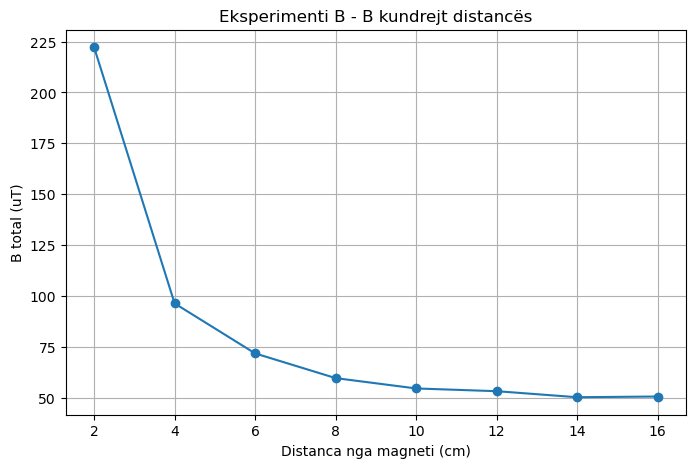

In [8]:
plt.figure(figsize=(8, 5))
plt.plot(b_1d["distance_cm"], b_1d["B_total_uT"], marker="o")
plt.xlabel("Distanca nga magneti (cm)")
plt.ylabel("B total (uT)")
plt.title("Eksperimenti B - B kundrejt distancës")
plt.grid(True)

plt.savefig(os.path.join(figs_folder, "B_total_vs_distance.png"), dpi=200, bbox_inches="tight")
plt.show()

## Grafiku i ndryshimit \(\Delta B\)

Ky grafik tregon vetëm ndikimin e magnetit, pasi është hequr fusha magnetike e ambientit.

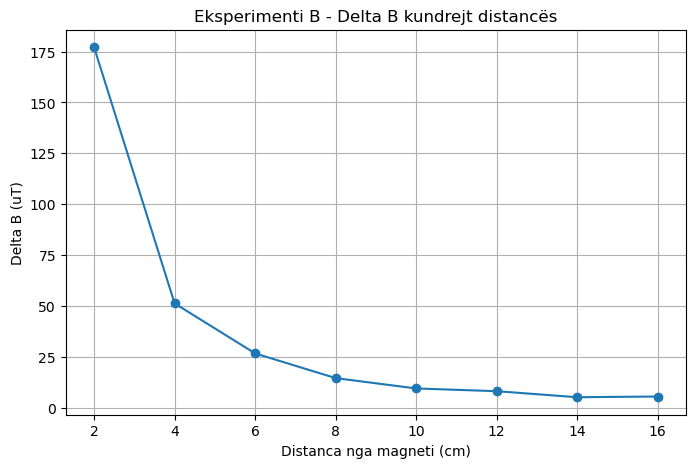

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(b_1d["distance_cm"], b_1d["DeltaB_uT"], marker="o")
plt.xlabel("Distanca nga magneti (cm)")
plt.ylabel("Delta B (uT)")
plt.title("Eksperimenti B - Delta B kundrejt distancës")
plt.grid(True)

plt.savefig(os.path.join(figs_folder, "B_delta_vs_distance.png"), dpi=200, bbox_inches="tight")
plt.show()

# Eksperimenti C - Harta 2D e Fushës Magnetike

Në eksperimentin C matet fusha magnetike në një rrjetë 2D.

Koordinatat janë në cm.

Në këtë version të thjeshtë, koordinatat janë vetëm pozitive:

\[
0, 2, 4, 6, 8, 10, 12
\]

Magneti merret në qendër të hartës:

\[
x = 6 \text{ cm}, \quad y = 6 \text{ cm}
\]

## Llogaritja e \(\Delta B\) për hartën 2D

Edhe për hartën 2D llogarisim ndryshimin nga fusha e ambientit.

In [10]:
b_map["DeltaB_uT"] = b_map["B_total_uT"] - B_ambient_mean

display(b_map.head())

,x_cm,y_cm,Bx_uT,By_uT,Bz_uT,B_total_uT,DeltaB_uT
0,0,0,13.74,-12.82,46.62,50.27,5.189333
1,2,0,14.24,-16.15,48.22,52.81,7.729333
2,4,0,18.25,-20.85,50.17,57.31,12.229333
3,6,0,21.55,-22.49,49.97,58.88,13.799333
4,8,0,27.17,-21.43,49.05,60.02,14.939333


## Scatter plot i hartës 2D

Çdo pikë në grafik përfaqëson një matje.

Ngjyra tregon madhësinë e fushës magnetike në atë pikë.

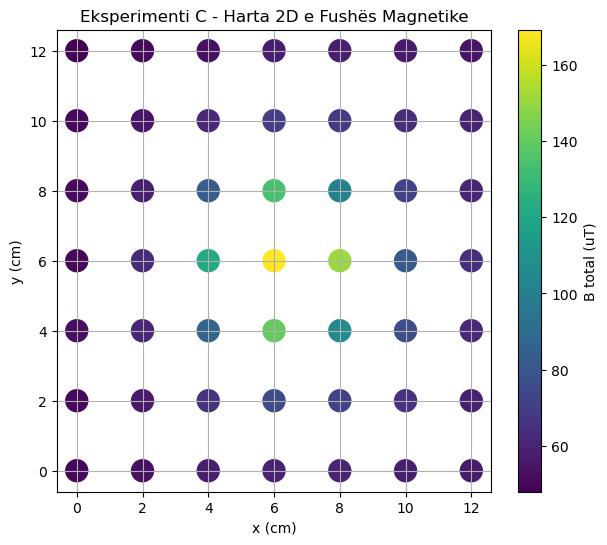

In [11]:
plt.figure(figsize=(7, 6))

scatter = plt.scatter(
    b_map["x_cm"],
    b_map["y_cm"],
    c=b_map["B_total_uT"],
    s=250
)

plt.colorbar(scatter, label="B total (uT)")
plt.xlabel("x (cm)")
plt.ylabel("y (cm)")
plt.title("Eksperimenti C - Harta 2D e Fushës Magnetike")
plt.grid(True)

plt.savefig(os.path.join(figs_folder, "C_map_2D_scatter.png"), dpi=200, bbox_inches="tight")
plt.show()

## Heatmap e fushës magnetike

Heatmap e bën më të lehtë të shohim zonat ku fusha magnetike është më e madhe.

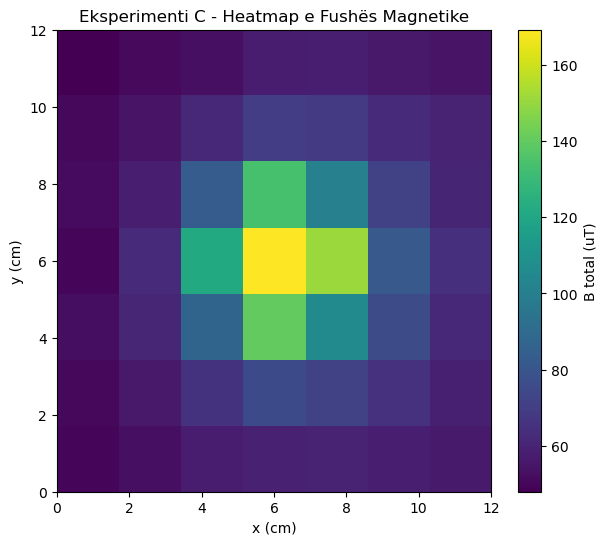

In [12]:
heatmap_data = b_map.pivot(index="y_cm", columns="x_cm", values="B_total_uT")

plt.figure(figsize=(7, 6))
plt.imshow(
    heatmap_data,
    origin="lower",
    extent=[
        b_map["x_cm"].min(),
        b_map["x_cm"].max(),
        b_map["y_cm"].min(),
        b_map["y_cm"].max()
    ],
    aspect="auto"
)

plt.colorbar(label="B total (uT)")
plt.xlabel("x (cm)")
plt.ylabel("y (cm)")
plt.title("Eksperimenti C - Heatmap e Fushës Magnetike")

plt.savefig(os.path.join(figs_folder, "C_heatmap_B_total.png"), dpi=200, bbox_inches="tight")
plt.show()

## Heatmap e \(\Delta B\)

Këtu shohim ndryshimin nga fusha e ambientit.

Kjo na ndihmon të dallojmë më qartë ndikimin e magnetit.

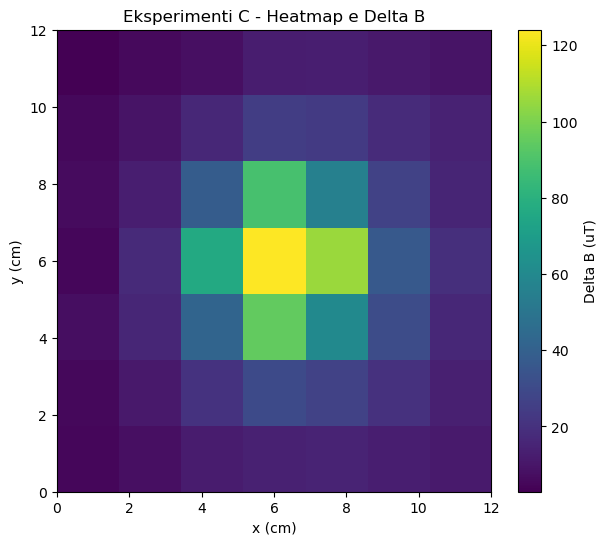

In [13]:
heatmap_delta = b_map.pivot(index="y_cm", columns="x_cm", values="DeltaB_uT")

plt.figure(figsize=(7, 6))
plt.imshow(
    heatmap_delta,
    origin="lower",
    extent=[
        b_map["x_cm"].min(),
        b_map["x_cm"].max(),
        b_map["y_cm"].min(),
        b_map["y_cm"].max()
    ],
    aspect="auto"
)

plt.colorbar(label="Delta B (uT)")
plt.xlabel("x (cm)")
plt.ylabel("y (cm)")
plt.title("Eksperimenti C - Heatmap e Delta B")

plt.savefig(os.path.join(figs_folder, "C_heatmap_delta_B.png"), dpi=200, bbox_inches="tight")
plt.show()

# Tabelë Përmbledhëse

Në këtë pjesë krijojmë një tabelë të shkurtër me rezultatet kryesore të laboratorit.

In [14]:
summary = pd.DataFrame({
    "Pjesa": [
        "Eksperimenti A - Ambjenti",
        "Eksperimenti B - 1D",
        "Eksperimenti C - 2D"
    ],
    "B_min_uT": [
        ambienti["B_total_uT"].min(),
        b_1d["B_total_uT"].min(),
        b_map["B_total_uT"].min()
    ],
    "B_max_uT": [
        ambienti["B_total_uT"].max(),
        b_1d["B_total_uT"].max(),
        b_map["B_total_uT"].max()
    ],
    "B_mean_uT": [
        ambienti["B_total_uT"].mean(),
        b_1d["B_total_uT"].mean(),
        b_map["B_total_uT"].mean()
    ],
    "DeltaB_max_uT": [
        0,
        b_1d["DeltaB_uT"].max(),
        b_map["DeltaB_uT"].max()
    ]
})

summary = summary.round(2)
display(summary)

,Pjesa,B_min_uT,B_max_uT,B_mean_uT,DeltaB_max_uT
0,Eksperimenti A - Ambjenti,44.34,46.06,45.08,0.00
1,Eksperimenti B - 1D,50.25,222.23,82.33,177.15
2,Eksperimenti C - 2D,47.96,169.19,71.19,124.11


# Diskutim

Nga rezultatet shihet se fusha magnetike e ambientit është afërsisht e qëndrueshme gjatë kohës së matjes.

Në eksperimentin B, fusha magnetike është më e madhe në distanca të vogla nga magneti. Kur distanca rritet, fusha magnetike zvogëlohet.

Në eksperimentin C, harta 2D tregon se zona pranë qendrës ka vlera më të mëdha të fushës magnetike. Kjo ndodh sepse magneti është vendosur në qendër të rrjetës, pra rreth pikës \(x = 6\) cm dhe \(y = 6\) cm.

Vlerat nuk janë perfekte sepse matjet me telefon mund të ndikohen nga:

- orientimi i telefonit
- objekte metalike pranë
- lëvizje të vogla gjatë matjes
- zhurma e sensorit
- fusha magnetike e Tokës

# Përfundim

Në këtë laborator u mat fusha magnetike në tre mënyra.

Fillimisht u mat fusha magnetike e ambientit. Pastaj u mat fusha magnetike në distanca të ndryshme nga magneti. Në fund u ndërtua një hartë 2D e fushës magnetike.

Rezultatet tregojnë se fusha magnetike është më e madhe pranë magnetit dhe zvogëlohet kur largohemi prej tij.

Telefoni mund të përdoret për të bërë matje të thjeshta të fushës magnetike, por rezultatet nuk janë shumë të sakta si me instrumente profesionale.

In [ ]:
S